In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [23]:
os.makedirs('../output/fourier/', exist_ok=True)
OUTPUT_DIR = '../output/fourier/'

In [45]:
# 各種変数の設定
fs = 2000  # サンプリング周波数 (Hz)
duration = 0.1  # 信号の長さ (秒)
t = np.linspace(0, duration, int(fs * duration))  # 時間軸

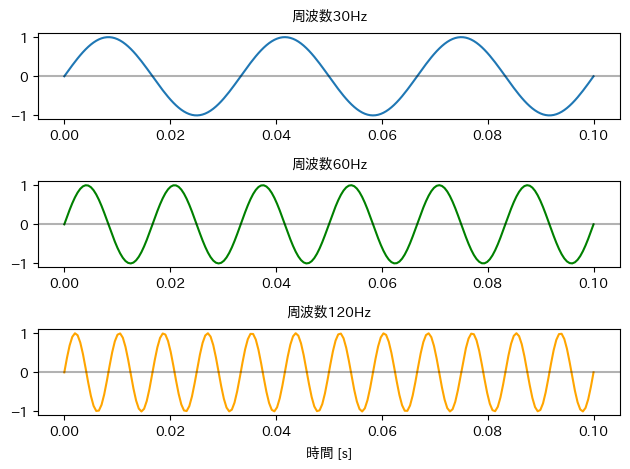

In [76]:
# 単純な信号の作成
signal_f30 = np.sin(2*np.pi*30*t)
signal_f60 = np.sin(2*np.pi*60*t)
signal_f120 = np.sin(2*np.pi*120*t)

# 可視化
plt.subplot(3, 1, 1)
plt.title('周波数30Hz', pad=10, fontsize=10)
plt.plot(t, signal_f30)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.subplot(3, 1, 2)
plt.title('周波数60Hz', pad=10, fontsize=10)
plt.plot(t, signal_f60, color='green')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.subplot(3, 1, 3)
plt.title('周波数120Hz', pad=10, fontsize=10)
plt.plot(t, signal_f120, color='orange')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('時間 [s]', labelpad=5)
plt.tight_layout();

plt.savefig(OUTPUT_DIR + 'figure2.png')

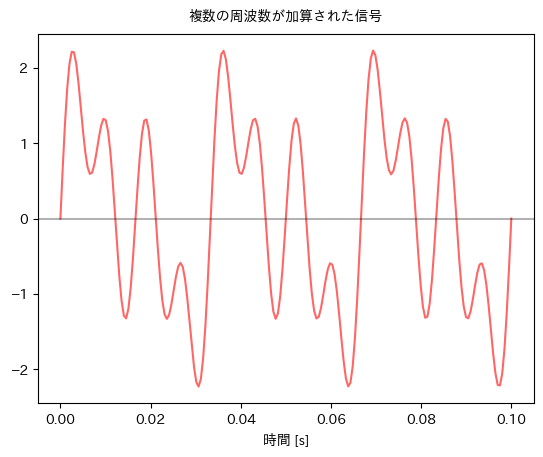

In [77]:
# 複合信号の生成
signal_sum = signal_f30 + signal_f60 + signal_f120

# 可視化
plt.plot(t, signal_sum, color='red', alpha=0.6)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('時間 [s]', labelpad=5);

plt.savefig(OUTPUT_DIR + 'figure3.png')

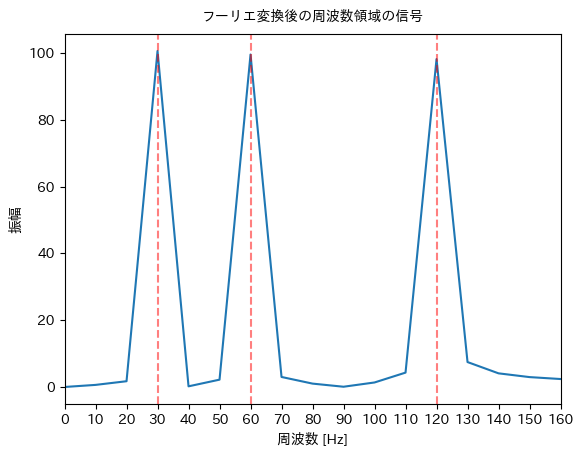

In [72]:
# 合成信号にフーリエ変換を適用
n = len(t)
fft_result = np.fft.fft(signal_sum)
fft_freq = np.fft.fftfreq(n, 1/fs)

# 可視化
amplitude = np.abs(fft_result)

plt.plot(fft_freq[:n//2], amplitude[:n//2])
plt.axvline(x=30, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=60, color='r', linestyle='--', alpha=0.5) 
plt.axvline(x=120, color='r', linestyle='--', alpha=0.5)
plt.xlabel('周波数 [Hz]')
plt.ylabel('振幅')
plt.xticks(np.arange(0, 161, 10))
plt.xlim(0, 160)

plt.savefig(OUTPUT_DIR + 'figure4.png')

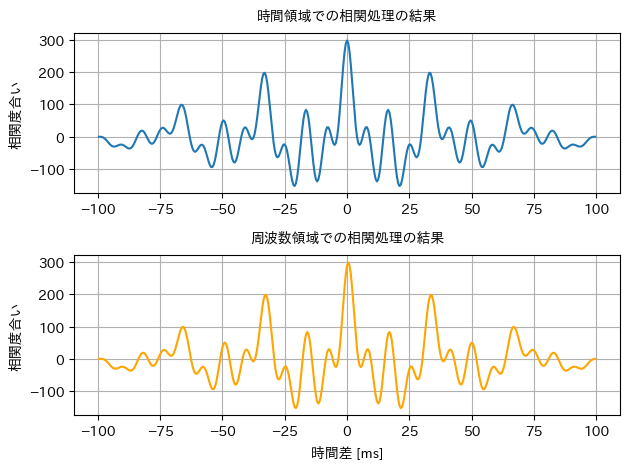

In [91]:
# 同じ合成信号を生成（コピー）
signal_copy = signal_sum

# 時間領域での相関処理
correlation_time = np.correlate(signal_sum, signal_copy, mode='full')

# 周波数領域での相関処理
fft1 = np.fft.fft(signal_sum, n=2*n-1)
fft2 = np.fft.fft(signal_copy, n=2*n-1)
fft_product = fft1 * np.conj(fft2)
correlation_freq = np.fft.ifftshift(np.fft.ifft(fft_product))
correlation_freq = np.real(correlation_freq)

# 可視化
lags = np.arange(-(len(signal_sum) - 1), len(signal_sum))
lag_times = lags / fs

plt.subplot(2, 1, 1)
plt.plot(lag_times * 1000, correlation_time)
plt.title('時間領域での相関処理の結果', pad=10, fontsize=10)
plt.ylabel('相関度合い')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(lag_times * 1000, correlation_freq, color='orange')
plt.title('周波数領域での相関処理の結果', pad=10, fontsize=10)
plt.xlabel('時間差 [ms]', labelpad=5)
plt.ylabel('相関度合い')
plt.grid(True)
plt.tight_layout();

plt.savefig(OUTPUT_DIR + 'figure5.png')